In [67]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [68]:
import random as rd
import time

In [69]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end='')
      else:
        print(f'{X[i][j]:d}',end='')
    print()

In [70]:
def create_matrix(Din,DigitosPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(1*(DigitosPorSimbolo-1),1*9**(DigitosPorSimbolo))
      Bin[i][j] = rd.randint(1*(DigitosPorSimbolo-1),1*9**(DigitosPorSimbolo))
  return [Ain,Bin]

In [71]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [72]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [73]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [74]:
def send_matrix(X,input,flag):
  file = open(f"teste{input}.txt","+w")

  if(flag):
    s = serial.Serial()
    s.port = "/dev/ttyUSB1"
    s.baudrate = 115200
    s.bytesize = 8
    s.open()
  Fs =10000
  cmp = len(str(X[0][0]))
  file.write(f"assign {input}[{0}] = "+"8'b"+str(11111111)+";\n")
  for i in range(X.shape[1]):
    strbin = ''
    for j in range(X.shape[0]):
      if(X[j][i] ==0):
        strbin+=str(X[j][i])
      else:
        strbin+=str(X[j][i])
    print('0b'+strbin,i)
    print(int('0b'+strbin,2))
    file.write(f"assign {input}[{i+1}] = "+"8'b"+strbin+";\n")
    if(flag):
      s.write(bytearray([int('0b'+strbin,2)]))
      time.sleep(1/Fs)  
  if(flag):
    s.write(bytearray([255]))
    s.close()  
  file.close()
  

In [75]:
M = create_matrix(Din = 8, DigitosPorSimbolo=1)
M[1]

array([[6, 2, 9, 6, 7, 8, 9, 3],
       [1, 1, 5, 9, 8, 1, 0, 5],
       [8, 4, 1, 1, 1, 9, 0, 0],
       [3, 5, 5, 0, 0, 5, 0, 0],
       [2, 1, 0, 4, 3, 2, 2, 0],
       [3, 2, 0, 7, 2, 5, 3, 5],
       [5, 0, 7, 1, 8, 6, 8, 9],
       [7, 6, 4, 5, 0, 2, 6, 4]])

In [76]:
M[0]@M[1]

array([[165,  93, 185, 145, 145, 189, 189, 145],
       [ 89,  62,  65, 102,  67, 101,  48,  54],
       [180, 104, 169, 237, 182, 202, 180, 149],
       [ 87,  58,  61, 139,  75,  89,  68,  87],
       [169,  72, 142, 124, 150, 195, 135, 135],
       [153,  86,  84,  86,  77, 152,  83,  90],
       [160, 122, 145, 178, 123, 160,  95, 122],
       [162, 117, 176, 151, 135, 148, 142, 134]])

M_p = shiftMatrixSystolic(M[0],M[1])

In [77]:
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"IMPUT_A",1)
    send_matrix(M_p[1],"IMPUT_B",1)
    
    break
    time.sleep(10)

---------------------- 0 --------------------------


SerialException: [Errno 5] could not open port /dev/ttyUSB1: [Errno 5] Input/output error: '/dev/ttyUSB1'

In [ ]:
M[0]@M[1]

array([[3, 3, 3, 1, 1, 3, 3, 3],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [2, 1, 2, 2, 2, 4, 5, 2],
       [2, 2, 2, 2, 2, 4, 3, 0],
       [4, 3, 3, 2, 1, 4, 3, 2],
       [2, 1, 1, 2, 1, 2, 1, 0],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [1, 1, 0, 2, 1, 1, 2, 2]])

In [ ]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]]))

In [78]:
M = create_matrix(Din = 8, DigitosPorSimbolo=1)

In [79]:
M[0]@M[1]

array([[187, 105, 210, 149, 146, 242, 191, 244],
       [ 86,  58,  96,  53,  58,  88,  96, 100],
       [165, 134, 127, 152, 124, 146, 150, 156],
       [ 80,  43,  69,  62,  56,  92,  87, 126],
       [133,  77, 158,  88,  94, 158, 174, 169],
       [254, 172, 241, 209, 184, 274, 249, 314],
       [155,  93, 169, 103, 147, 215, 146, 197],
       [152, 110, 112, 116, 127, 139, 154, 148]])

In [80]:
M

[array([[3, 9, 2, 4, 3, 9, 2, 8],
        [2, 1, 0, 2, 2, 5, 3, 2],
        [9, 1, 3, 2, 5, 1, 8, 3],
        [0, 2, 3, 1, 5, 1, 3, 3],
        [1, 0, 2, 5, 3, 5, 9, 4],
        [7, 5, 5, 4, 9, 7, 7, 8],
        [2, 9, 3, 7, 4, 7, 2, 3],
        [7, 5, 1, 3, 5, 2, 9, 1]]),
 array([[7, 9, 4, 9, 6, 4, 2, 1],
        [3, 0, 0, 2, 5, 5, 2, 4],
        [8, 7, 4, 6, 7, 9, 1, 9],
        [0, 0, 7, 1, 4, 8, 2, 0],
        [3, 2, 1, 1, 1, 1, 4, 8],
        [8, 6, 9, 1, 4, 6, 7, 9],
        [5, 2, 3, 2, 3, 3, 9, 5],
        [4, 0, 9, 9, 1, 9, 8, 9]])]

In [81]:
M_p[0]

array([[0, 0, 0, 0, 0, 0, 0, 9, 1, 0, 6, 2, 6, 7, 5],
       [0, 0, 0, 0, 0, 0, 2, 4, 4, 3, 3, 4, 0, 2, 0],
       [0, 0, 0, 0, 0, 9, 6, 2, 3, 9, 9, 3, 5, 0, 0],
       [0, 0, 0, 0, 2, 5, 2, 0, 1, 8, 0, 4, 0, 0, 0],
       [0, 0, 0, 5, 4, 8, 1, 1, 4, 8, 2, 0, 0, 0, 0],
       [0, 0, 0, 2, 9, 2, 2, 3, 5, 5, 0, 0, 0, 0, 0],
       [0, 2, 9, 5, 7, 2, 5, 2, 7, 0, 0, 0, 0, 0, 0],
       [3, 6, 1, 8, 5, 1, 6, 9, 0, 0, 0, 0, 0, 0, 0]])

In [82]:
M_p[1]

array([[0, 0, 0, 0, 0, 0, 0, 6, 1, 8, 3, 2, 3, 5, 7],
       [0, 0, 0, 0, 0, 0, 2, 1, 4, 5, 1, 2, 0, 6, 0],
       [0, 0, 0, 0, 0, 9, 5, 1, 5, 0, 0, 7, 4, 0, 0],
       [0, 0, 0, 0, 6, 9, 1, 0, 4, 7, 1, 5, 0, 0, 0],
       [0, 0, 0, 7, 8, 1, 0, 3, 2, 8, 0, 0, 0, 0, 0],
       [0, 0, 8, 1, 9, 5, 2, 5, 6, 2, 0, 0, 0, 0, 0],
       [0, 9, 0, 0, 0, 2, 3, 8, 6, 0, 0, 0, 0, 0, 0],
       [3, 5, 0, 0, 0, 5, 9, 4, 0, 0, 0, 0, 0, 0, 0]])

In [83]:
def send_matrix(X,input,flag):
  file = open(f"teste{input}.txt","+w")
  file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    print(f'{strbin:08d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"INPUT_A",0)
    send_matrix(M_p[1],"INPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------
00000007 0
00000025 1
00000791 2
00001533 3
00000575 4
00922442 5
02135979 6
31313721 7
90255730 8
22519800 9
42134000 10
35830000 11
93300000 12
22000000 13
80000000 14
00000001 0
00000024 1
00000429 2
00006510 3
00095928 4
00427849 5
09064175 6
70411699 7
37714380 8
80113900 9
02921000 10
36390000 11
82900000 12
50000000 13
40000000 14


In [ ]:
M[0]

array([[1, 0, 1, 1, 0, 1, 1, 0],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 1, 0, 0, 1, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 1, 1],
       [0, 1, 1, 1, 0, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 0, 1, 0, 1, 0, 0, 0]])

In [ ]:
M[0]@M[1]

array([[3, 3, 3, 1, 1, 3, 3, 3],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [2, 1, 2, 2, 2, 4, 5, 2],
       [2, 2, 2, 2, 2, 4, 3, 0],
       [4, 3, 3, 2, 1, 4, 3, 2],
       [2, 1, 1, 2, 1, 2, 1, 0],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [1, 1, 0, 2, 1, 1, 2, 2]])

In [ ]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])]

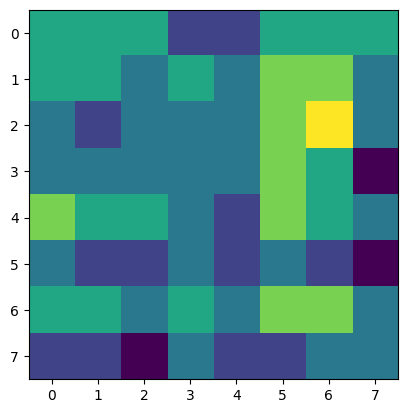

In [ ]:
plt.imshow(M[0]@M[1])

plt.show()

In [ ]:

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"IMPUT_A",0)
    send_matrix(M_p[1],"IMPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------
00000001 0
00000010 1
00000011 2
00000110 3
00001011 4
00111110 5
01101100 6
11010010 7
01011010 8
11101000 9
11111000 10
00110000 11
11100000 12
11000000 13
00000000 14
00000001 0
00000010 1
00000001 2
00000000 3
00000000 4
00010111 5
00010110 6
00001110 7
11110110 8
11001100 9
10100000 10
00100000 11
11000000 12
00000000 13
00000000 14


In [ ]:
M[0]

array([[1, 0, 1, 1, 0, 1, 1, 0],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 1, 0, 0, 1, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 1, 1],
       [0, 1, 1, 1, 0, 1, 1, 1],
       [0, 1, 0, 1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 0, 1, 0, 1, 0, 0, 0]])

In [ ]:
M[1]

array([[0, 0, 0, 0, 0, 0, 1, 1],
       [1, 0, 0, 1, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 0, 0, 1],
       [1, 1, 1, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 1, 1, 1, 0],
       [1, 0, 1, 0, 0, 1, 1, 1],
       [0, 1, 1, 0, 1, 1, 1, 0],
       [0, 0, 0, 0, 0, 1, 1, 0]])

In [ ]:
M[0]@M[1]

array([[3, 3, 3, 1, 1, 3, 3, 3],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [2, 1, 2, 2, 2, 4, 5, 2],
       [2, 2, 2, 2, 2, 4, 3, 0],
       [4, 3, 3, 2, 1, 4, 3, 2],
       [2, 1, 1, 2, 1, 2, 1, 0],
       [3, 3, 2, 3, 2, 4, 4, 2],
       [1, 1, 0, 2, 1, 1, 2, 2]])

In [ ]:
s = serial.Serial()

s.port = "/dev/ttyUSB1"
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [ ]:
i =1
s.write(bytearray([int(i)]))


1

In [ ]:
serial.Serial()

Serial<id=0x7f8d3cb31060, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)